# Insurance Cost Prediction

## Feature Engineering

### 1. Import Libraries
### 2. Load Dataset
### 3. Create BMI Feature
### 4. Analyze BMI
### 5. Outlier Treatment Decision
### 6. Prepare Features and Target
### 7. Train-Test Split
### 8. Feature Scaling
### 9. Save Processed Data

In [1]:
# Import Libraries
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# Load Dataset
df = pd.read_csv('../data/insurance.csv')

In [3]:
df.head()

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice
0,45,0,0,0,0,155,57,0,0,0,25000
1,60,1,0,0,0,180,73,0,0,0,29000
2,36,1,1,0,0,158,59,0,0,1,23000
3,52,1,1,0,1,183,93,0,0,2,28000
4,38,0,0,0,1,166,88,0,0,1,23000


In [4]:
df["Height_m"] = df["Height"] / 100

In [5]:
df['BMI'] = df['Weight'] / (df['Height_m'] ** 2)

In [6]:
df['BMI'].head()

0    23.725286
1    22.530864
2    23.634033
3    27.770313
4    31.934969
Name: BMI, dtype: float64

In [7]:
df[["Height", "Weight", "BMI"]].head()

,Height,Weight,BMI
0,155,57,23.725286
1,180,73,22.530864
2,158,59,23.634033
3,183,93,27.770313
4,166,88,31.934969


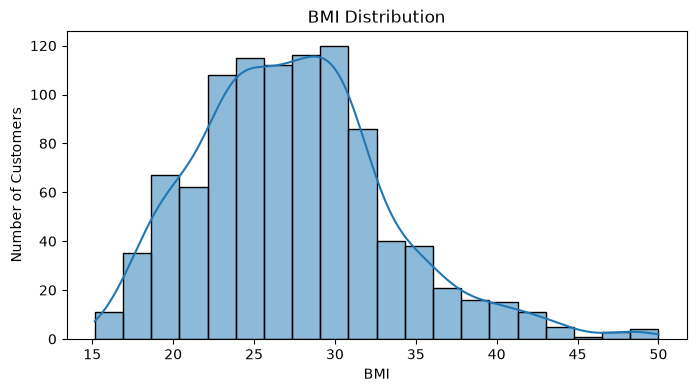

In [8]:
# Analyze BMI Distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.histplot(data=df, x="BMI", bins=20, kde=True)
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Number of Customers")
plt.show()

## BMI Analysis

BMI provides a combined measure of height and weight, making it a more meaningful health indicator than either variable alone.

Higher BMI values may be associated with increased health risks and could potentially influence insurance premium prices.

In [11]:
# Executive KPI Dataset
summary = pd.DataFrame({
    "Total Customers":[len(df)],
    "Average Age":[df["Age"].mean()],
    "Average Premium":[df["PremiumPrice"].mean()],
    "Average BMI":[df["BMI"].mean()],
    "Average Weight":[df["Weight"].mean()]
})
summary

,Total Customers,Average Age,Average Premium,Average BMI,Average Weight
0,986,41.745436,24336.713996,27.460709,76.950304


In [12]:
# Save Executive Summary
summary.to_csv(
    "../output/executive_summary.csv",
    index=False
)

In [9]:
# Check Correlation of BMI
df.corr()["PremiumPrice"].sort_values(ascending=False)

PremiumPrice               1.000000
Age                        0.697540
AnyTransplants             0.289056
NumberOfMajorSurgeries     0.264250
AnyChronicDiseases         0.208610
BloodPressureProblems      0.167097
Weight                     0.141507
BMI                        0.103812
HistoryOfCancerInFamily    0.083139
Diabetes                   0.076209
Height_m                   0.026910
Height                     0.026910
KnownAllergies             0.012103
Name: PremiumPrice, dtype: float64

## Correaltion of BMI

Weight is a stronger individual predictor than BMI in this dataset.

Creating BMI did not improve the linear relationship with PremiumPrice.

# Outlier Treatment Decision

Weight → 16 outliers
PremiumPrice → 6 outliers

Outliers identified during the EDA stage were retained in the dataset.

These observations may represent genuine high-risk customers rather than incorrect records. 

Retaining them allows the machine learning models to learn from real-world premium variations.

In [59]:
# Prepare Features and Target
df = df.drop("Height_m", axis=1)

In [60]:
# Split the dataset into features and target variable
X = df.drop("PremiumPrice", axis=1)
y = df["PremiumPrice"]

In [61]:
print(X.shape)
print(y.shape)

(986, 11)
(986,)


In [62]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (788, 11)
Testing set: (198, 11)


In [63]:
# Feature Scaling
scaler = StandardScaler()
train_scaled = scaler.fit_transform(X_train)
test_scaled = scaler.transform(X_test)

In [64]:
# Convert Back to DataFrame
X_train_scaled = pd.DataFrame(train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(test_scaled, columns=X_test.columns)

In [65]:
X_train_scaled.head()

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,BMI
0,-1.617536,-0.857720,-0.928916,-0.243187,-0.470856,-2.219275,-1.519089,-0.524482,-0.359082,-0.874799,-0.279682
1,-0.763949,-0.857720,1.076524,-0.243187,-0.470856,-0.620930,0.691260,-0.524482,-0.359082,-0.874799,0.956170
2,1.156620,1.165882,-0.928916,-0.243187,-0.470856,-2.119378,-0.137621,-0.524482,-0.359082,-0.874799,1.218088
3,-0.763949,-0.857720,1.076524,-0.243187,-0.470856,0.278138,0.553113,-0.524482,-0.359082,-0.874799,0.269701
4,-1.119610,1.165882,1.076524,-0.243187,-0.470856,-0.121448,-0.482988,-0.524482,2.784880,0.433249,-0.397867


In [66]:
# Save Processed Data
X_train_scaled.to_csv("../output/X_train_scaled.csv", index=False)
X_test_scaled.to_csv("../output/X_test_scaled.csv", index=False)
y_train.to_csv("../output/y_train.csv", index=False)
y_test.to_csv("../output/y_test.csv", index=False)

In [67]:
# Save engineered dataset (with BMI)
df.to_csv("../output/insurance_with_bmi.csv", index=False)

# Feature Engineering Summary

### Features Created
- A new feature, **Body Mass Index (BMI)**, was created using Height and Weight to better represent an individual's body composition.

Correlation analysis showed that BMI has a positive correlation (0.1038) with PremiumPrice. Although this correlation is weaker than that of Weight (0.1415), BMI was retained because it is a clinically meaningful feature and may improve the performance of certain machine learning models.

The usefulness of BMI will be further evaluated during the model training and feature importance analysis stages.

### Outlier Decision
- Outliers were retained because they may represent genuine high-risk customers.

### Data Preparation
- Features and target variable were separated.
- The dataset was split into training (80%) and testing (20%) sets.
- Numerical features were standardized using StandardScaler.

### Output Files
- insurance_with_bmi.csv
- X_train_scaled.csv
- X_test_scaled.csv
- y_train.csv
- y_test.csv

These processed datasets will be used for machine learning model development in the next stage.